In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
palo_df = pd.read_csv(
    "data/raw/ChargePoint Data CY20Q4.csv",
    low_memory=False
)

print("Rows:", palo_df.shape[0])
print("Columns:", palo_df.shape[1])

palo_df.head()

Rows: 259415
Columns: 33


,Station Name,MAC Address,Org Name,Start Date,Start Time Zone,End Date,End Time Zone,Transaction Date (Pacific Time),Total Duration (hh:mm:ss),Charging Time (hh:mm:ss),...,Longitude,Currency,Fee,Ended By,Plug In Event Id,Driver Postal Code,User ID,County,System S/N,Model Number
0,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/29/2011 20:17,PDT,7/29/2011 23:20,PDT,7/29/2011 23:20,3:03:32,1:54:03,...,-122.160309,USD,0.0,Plug Out at Vehicle,3,95124.0,3284,NaN,NaN,NaN
1,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 0:00,PDT,7/30/2011 0:02,PDT,7/30/2011 0:02,0:02:06,0:01:54,...,-122.160309,USD,0.0,Customer,4,94301.0,4169,NaN,NaN,NaN
2,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 8:16,PDT,7/30/2011 12:34,PDT,7/30/2011 12:34,4:17:32,4:17:28,...,-122.160309,USD,0.0,Plug Out at Vehicle,5,94301.0,4169,NaN,NaN,NaN
3,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 14:51,PDT,7/30/2011 16:55,PDT,7/30/2011 16:55,2:03:24,2:02:58,...,-122.160309,USD,0.0,Customer,6,94302.0,2545,NaN,NaN,NaN
4,PALO ALTO CA / HAMILTON #1,000D:6F00:015A:9D76,City of Palo Alto,7/30/2011 18:51,PDT,7/30/2011 20:03,PDT,7/30/2011 20:03,1:11:24,0:43:54,...,-122.160309,USD,0.0,Plug Out at Vehicle,7,94043.0,3765,NaN,NaN,NaN


In [6]:
palo_df.columns.tolist()

['Station Name',
 'MAC Address',
 'Org Name',
 'Start Date',
 'Start Time Zone',
 'End Date',
 'End Time Zone',
 'Transaction Date (Pacific Time)',
 'Total Duration (hh:mm:ss)',
 'Charging Time (hh:mm:ss)',
 'Energy (kWh)',
 'GHG Savings (kg)',
 'Gasoline Savings (gallons)',
 'Port Type',
 'Port Number',
 'Plug Type',
 'EVSE ID',
 'Address 1',
 'City',
 'State/Province',
 'Postal Code',
 'Country',
 'Latitude',
 'Longitude',
 'Currency',
 'Fee',
 'Ended By',
 'Plug In Event Id',
 'Driver Postal Code',
 'User ID',
 'County',
 'System S/N',
 'Model Number']

In [7]:
important_columns = [
    "Station Name",
    "Start Date",
    "Start Time Zone",
    "Energy (kWh)",
    "City"
]

palo_df[important_columns].head()

,Station Name,Start Date,Start Time Zone,Energy (kWh),City
0,PALO ALTO CA / HAMILTON #1,7/29/2011 20:17,PDT,6.249457,Palo Alto
1,PALO ALTO CA / HAMILTON #1,7/30/2011 0:00,PDT,0.106588,Palo Alto
2,PALO ALTO CA / HAMILTON #1,7/30/2011 8:16,PDT,14.951777,Palo Alto
3,PALO ALTO CA / HAMILTON #1,7/30/2011 14:51,PDT,7.159643,Palo Alto
4,PALO ALTO CA / HAMILTON #1,7/30/2011 18:51,PDT,1.957765,Palo Alto


In [8]:
print("Missing values:")

print(
    palo_df[important_columns]
    .isnull()
    .sum()
)

print("\nExact duplicate rows:")
print(palo_df.duplicated().sum())

Missing values:
Station Name       0
Start Date         0
Start Time Zone    0
Energy (kWh)       0
City               0
dtype: int64

Exact duplicate rows:
4


In [9]:
clean_df = palo_df.drop_duplicates().copy()

clean_df = clean_df[important_columns].copy()

clean_df = clean_df.rename(
    columns={
        "Station Name": "stationName",
        "Start Date": "startDate",
        "Start Time Zone": "timeZone",
        "Energy (kWh)": "energy",
        "City": "city"
    }
)

print("Rows after removing duplicates:", len(clean_df))

clean_df.head()

Rows after removing duplicates: 259411


,stationName,startDate,timeZone,energy,city
0,PALO ALTO CA / HAMILTON #1,7/29/2011 20:17,PDT,6.249457,Palo Alto
1,PALO ALTO CA / HAMILTON #1,7/30/2011 0:00,PDT,0.106588,Palo Alto
2,PALO ALTO CA / HAMILTON #1,7/30/2011 8:16,PDT,14.951777,Palo Alto
3,PALO ALTO CA / HAMILTON #1,7/30/2011 14:51,PDT,7.159643,Palo Alto
4,PALO ALTO CA / HAMILTON #1,7/30/2011 18:51,PDT,1.957765,Palo Alto


In [10]:
clean_df["timeZone"] = (
    clean_df["timeZone"]
    .str.strip()
    .str.upper()
)

clean_df["timeZone"].value_counts()

timeZone
PDT    166762
PST     92618
UTC        31
Name: count, dtype: int64

In [11]:
clean_df["startDate"] = pd.to_datetime(
    clean_df["startDate"],
    errors="coerce"
)

clean_df["energy"] = pd.to_numeric(
    clean_df["energy"],
    errors="coerce"
)

In [12]:
utc_rows = clean_df["timeZone"] == "UTC"

clean_df.loc[utc_rows, "startDate"] = (
    pd.to_datetime(
        clean_df.loc[utc_rows, "startDate"],
        utc=True
    )
    .dt.tz_convert("America/Los_Angeles")
    .dt.tz_localize(None)
)

print("UTC records converted:", utc_rows.sum())

UTC records converted: 31


In [13]:
print(
    "Missing start dates:",
    clean_df["startDate"].isnull().sum()
)

print(
    "Missing energy values:",
    clean_df["energy"].isnull().sum()
)

print(
    "Negative energy values:",
    (clean_df["energy"] < 0).sum()
)

print("\nCities:")
print(clean_df["city"].value_counts())

Missing start dates: 0
Missing energy values: 0
Negative energy values: 0

Cities:
city
Palo Alto    259411
Name: count, dtype: int64


In [14]:
clean_df = clean_df.dropna(
    subset=["startDate", "energy"]
)

clean_df = clean_df[
    clean_df["energy"] >= 0
].copy()

clean_df["city"] = clean_df["city"].str.strip()

clean_df = clean_df[
    clean_df["city"] == "Palo Alto"
].copy()

clean_df = clean_df.sort_values(
    "startDate"
).reset_index(drop=True)

print("Clean sessions:", len(clean_df))

Clean sessions: 259411


In [15]:
clean_df["date"] = (
    clean_df["startDate"]
    .dt.normalize()
)

print("First date:", clean_df["date"].min())
print("Last date:", clean_df["date"].max())

clean_df.head()

First date: 2011-07-29 00:00:00
Last date: 2020-12-31 00:00:00


,stationName,startDate,timeZone,energy,city,date
0,PALO ALTO CA / HAMILTON #1,2011-07-29 20:17:00,PDT,6.249457,Palo Alto,2011-07-29
1,PALO ALTO CA / HAMILTON #1,2011-07-30 00:00:00,PDT,0.106588,Palo Alto,2011-07-30
2,PALO ALTO CA / HAMILTON #1,2011-07-30 08:16:00,PDT,14.951777,Palo Alto,2011-07-30
3,PALO ALTO CA / HAMILTON #1,2011-07-30 14:51:00,PDT,7.159643,Palo Alto,2011-07-30
4,PALO ALTO CA / HAMILTON #1,2011-07-30 18:51:00,PDT,1.957765,Palo Alto,2011-07-30


In [16]:
daily_df = clean_df.groupby("date").agg(
    dailyEnergy=("energy", "sum"),
    sessionCount=("energy", "count"),
    activeStations=("stationName", "nunique"),
    averageEnergyPerSession=("energy", "mean")
)

daily_df = daily_df.reset_index()

daily_df.head()

,date,dailyEnergy,sessionCount,activeStations,averageEnergyPerSession
0,2011-07-29,6.249457,1,1,6.249457
1,2011-07-30,28.978653,5,1,5.795731
2,2011-07-31,37.209163,3,1,12.403054
3,2011-08-01,5.041244,1,1,5.041244
4,2011-08-02,16.210423,3,2,5.403474


In [17]:
daily_df = daily_df.sort_values(
    "date"
).reset_index(drop=True)

print("Number of daily records:", len(daily_df))
print("First date:", daily_df["date"].min())
print("Last date:", daily_df["date"].max())

daily_df.head()

Number of daily records: 3444
First date: 2011-07-29 00:00:00
Last date: 2020-12-31 00:00:00


,date,dailyEnergy,sessionCount,activeStations,averageEnergyPerSession
0,2011-07-29,6.249457,1,1,6.249457
1,2011-07-30,28.978653,5,1,5.795731
2,2011-07-31,37.209163,3,1,12.403054
3,2011-08-01,5.041244,1,1,5.041244
4,2011-08-02,16.210423,3,2,5.403474


In [18]:
duplicate_dates = daily_df["date"].duplicated().sum()

all_dates = pd.date_range(
    start=daily_df["date"].min(),
    end=daily_df["date"].max(),
    freq="D"
)

missing_dates = all_dates.difference(
    daily_df["date"]
)

print("Duplicate dates:", duplicate_dates)
print("Missing dates:", len(missing_dates))

Duplicate dates: 0
Missing dates: 0


In [19]:
daily_df[
    [
        "dailyEnergy",
        "sessionCount",
        "activeStations",
        "averageEnergyPerSession"
    ]
].describe()

,dailyEnergy,sessionCount,activeStations,averageEnergyPerSession
count,3444.000000,3444.000000,3444.000000,3444.000000
mean,643.581218,75.322590,16.050232,8.114257
std,489.045259,52.710418,9.747052,1.595404
min,3.575593,1.000000,1.000000,1.191864
25%,205.371656,28.000000,5.000000,7.112091
50%,473.165500,57.000000,17.000000,8.166388
75%,1092.051500,127.250000,24.000000,9.015002
max,1962.229000,193.000000,33.000000,19.997625


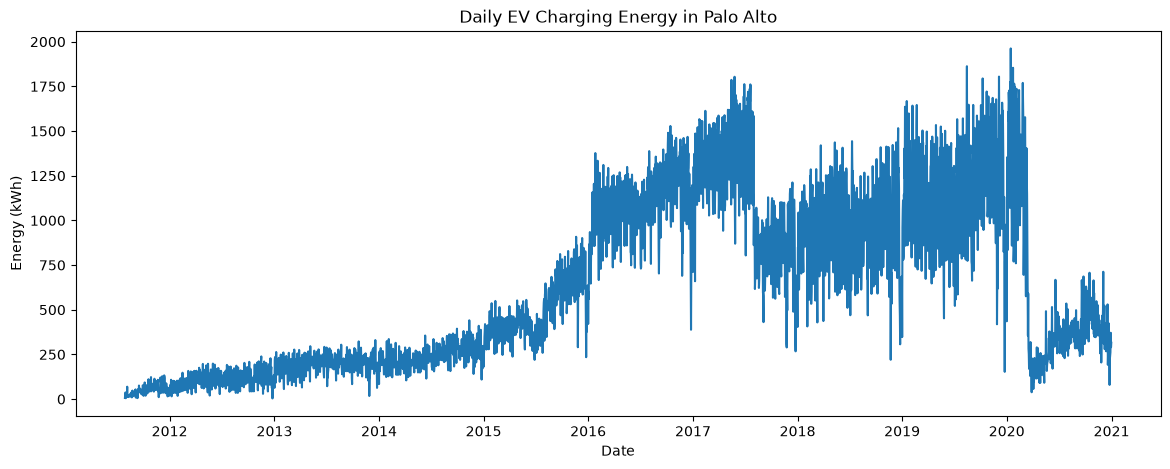

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_df["date"],
    daily_df["dailyEnergy"]
)

plt.title("Daily EV Charging Energy in Palo Alto")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.show()

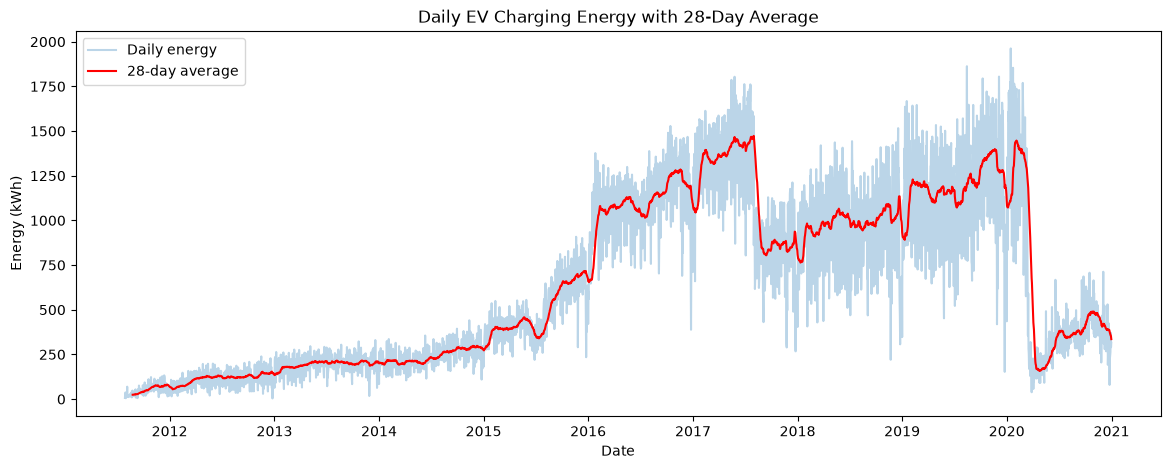

In [21]:
rolling_average = (
    daily_df["dailyEnergy"]
    .rolling(28)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_df["date"],
    daily_df["dailyEnergy"],
    alpha=0.3,
    label="Daily energy"
)

plt.plot(
    daily_df["date"],
    rolling_average,
    color="red",
    label="28-day average"
)

plt.title("Daily EV Charging Energy with 28-Day Average")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.show()

In [22]:
model_df = daily_df.copy()

In [23]:
model_df["energyLag1"] = (
    model_df["dailyEnergy"].shift(1)
)

model_df["energyLag7"] = (
    model_df["dailyEnergy"].shift(7)
)

model_df["energyLag14"] = (
    model_df["dailyEnergy"].shift(14)
)

model_df["energyLag28"] = (
    model_df["dailyEnergy"].shift(28)
)

In [24]:
past_energy = model_df["dailyEnergy"].shift(1)

model_df["rollingMean7"] = (
    past_energy.rolling(7).mean()
)

model_df["rollingMean14"] = (
    past_energy.rolling(14).mean()
)

model_df["rollingMean28"] = (
    past_energy.rolling(28).mean()
)

In [25]:
model_df["dayOfWeek"] = (
    model_df["date"].dt.dayofweek
)

model_df["month"] = (
    model_df["date"].dt.month
)

model_df["isWeekend"] = (
    model_df["dayOfWeek"] >= 5
).astype(int)

In [26]:
model_df = model_df.dropna().reset_index(drop=True)

print("Daily records before features:", len(daily_df))
print("Modeling records:", len(model_df))

model_df.head()

Daily records before features: 3444
Modeling records: 3416


,date,dailyEnergy,sessionCount,activeStations,averageEnergyPerSession,energyLag1,energyLag7,energyLag14,energyLag28,rollingMean7,rollingMean14,rollingMean28,dayOfWeek,month,isWeekend
0,2011-08-26,17.175258,4,2,4.293814,14.774353,31.553527,13.364580,6.249457,28.339297,25.289374,24.390521,4,8,0
1,2011-08-27,27.324761,4,2,6.831190,17.175258,12.648807,21.485198,28.978653,26.285259,25.561566,24.780728,5,8,1
2,2011-08-28,34.545546,5,2,6.909109,27.324761,38.561442,22.584837,37.209163,28.381824,25.978677,24.721660,6,8,1
3,2011-08-29,20.875614,5,2,4.175123,34.545546,9.631848,19.313083,5.041244,27.808124,26.833014,24.626531,0,8,0
4,2011-08-30,26.982022,4,2,6.745506,20.875614,43.649644,27.104459,16.210423,29.414376,26.944623,25.192044,1,8,0


In [27]:
feature_columns = [
    "energyLag1",
    "energyLag7",
    "energyLag14",
    "energyLag28",
    "rollingMean7",
    "rollingMean14",
    "rollingMean28",
    "dayOfWeek",
    "month",
    "isWeekend"
]

target_column = "dailyEnergy"

In [28]:
total_rows = len(model_df)

train_end = int(total_rows * 0.60)
validation_end = int(total_rows * 0.80)

print("Total records:", total_rows)
print("Training records:", train_end)
print("Validation records:", validation_end - train_end)
print("Test records:", total_rows - validation_end)

Total records: 3416
Training records: 2049
Validation records: 683
Test records: 684


In [29]:
train_df = model_df.iloc[
    :train_end
].copy()

validation_df = model_df.iloc[
    train_end:validation_end
].copy()

test_df = model_df.iloc[
    validation_end:
].copy()

In [30]:
print("TRAINING")
print(train_df["date"].min())
print(train_df["date"].max())
print()

print("VALIDATION")
print(validation_df["date"].min())
print(validation_df["date"].max())
print()

print("TEST")
print(test_df["date"].min())
print(test_df["date"].max())

TRAINING
2011-08-26 00:00:00
2017-04-04 00:00:00

VALIDATION
2017-04-05 00:00:00
2019-02-16 00:00:00

TEST
2019-02-17 00:00:00
2020-12-31 00:00:00


In [31]:
X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

In [32]:
print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

Training: (2049, 10)
Validation: (683, 10)
Test: (684, 10)


In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [34]:
validation_results = validation_df[
    ["date", "dailyEnergy"]
].copy()

validation_results["seasonalNaivePrediction"] = (
    validation_df["energyLag7"].values
)

validation_results.head()

,date,dailyEnergy,seasonalNaivePrediction
2049,2017-04-05,1277.004,1461.583
2050,2017-04-06,1293.922,1497.271
2051,2017-04-07,1477.299,1586.593
2052,2017-04-08,1240.263,1013.780
2053,2017-04-09,1058.400,1112.360


In [35]:
seasonal_naive_mae = mean_absolute_error(
    validation_results["dailyEnergy"],
    validation_results["seasonalNaivePrediction"]
)

seasonal_naive_rmse = np.sqrt(
    mean_squared_error(
        validation_results["dailyEnergy"],
        validation_results["seasonalNaivePrediction"]
    )
)

print("Seasonal-Naive Validation Results")
print("MAE:", round(seasonal_naive_mae, 2))
print("RMSE:", round(seasonal_naive_rmse, 2))

Seasonal-Naive Validation Results
MAE: 155.6
RMSE: 227.97


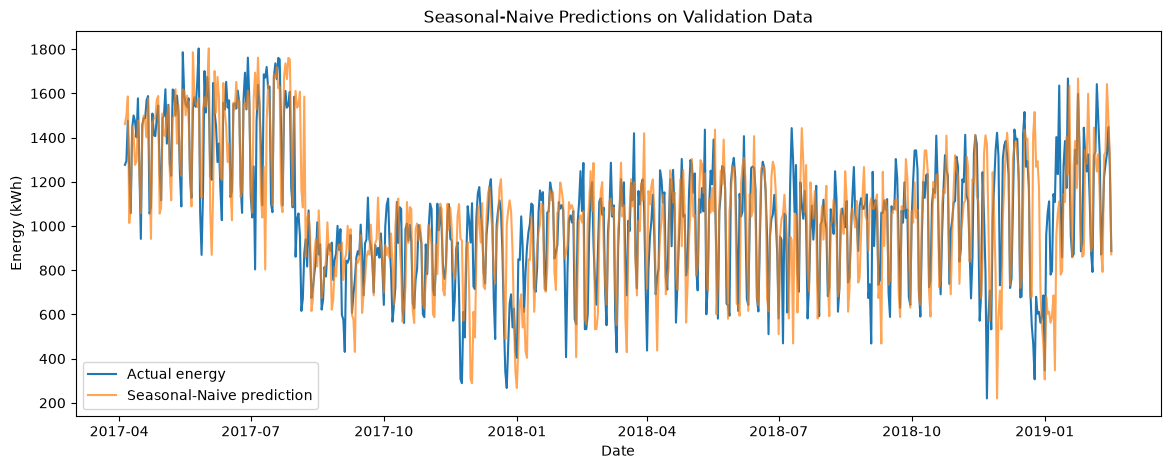

In [36]:
plt.figure(figsize=(14, 5))

plt.plot(
    validation_results["date"],
    validation_results["dailyEnergy"],
    label="Actual energy"
)

plt.plot(
    validation_results["date"],
    validation_results["seasonalNaivePrediction"],
    label="Seasonal-Naive prediction",
    alpha=0.7
)

plt.title("Seasonal-Naive Predictions on Validation Data")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.show()

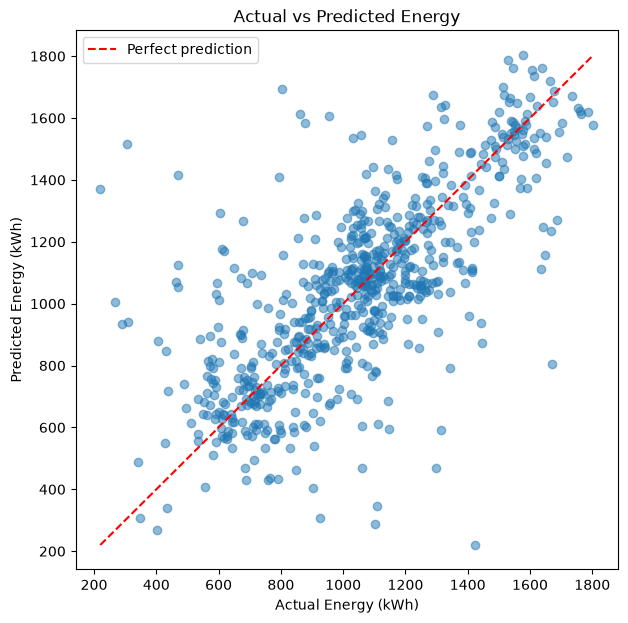

In [37]:
plt.figure(figsize=(7, 7))

plt.scatter(
    validation_results["dailyEnergy"],
    validation_results["seasonalNaivePrediction"],
    alpha=0.5
)

lowest_value = validation_results["dailyEnergy"].min()
highest_value = validation_results["dailyEnergy"].max()

plt.plot(
    [lowest_value, highest_value],
    [lowest_value, highest_value],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Energy")
plt.xlabel("Actual Energy (kWh)")
plt.ylabel("Predicted Energy (kWh)")
plt.legend()
plt.show()

In [47]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [48]:
rf_tuning_results = []

for trees in [100, 200]:
    
    for depth in [10, 20, 30]:
        
        for leaf_size in [1, 2]:
            
            rf_model = RandomForestRegressor(
                n_estimators=trees,
                max_depth=depth,
                min_samples_leaf=leaf_size,
                random_state=42
            )
            
            rf_model.fit(
                X_train,
                y_train
            )
            
            prediction = rf_model.predict(
                X_validation
            )
            
            mae = mean_absolute_error(
                y_validation,
                prediction
            )
            
            rmse = np.sqrt(
                mean_squared_error(
                    y_validation,
                    prediction
                )
            )
            
            rf_tuning_results.append(
                [
                    trees,
                    depth,
                    leaf_size,
                    mae,
                    rmse
                ]
            )

In [49]:
rf_tuning_df = pd.DataFrame(
    rf_tuning_results,
    columns=[
        "nEstimators",
        "maxDepth",
        "minSamplesLeaf",
        "MAE",
        "RMSE"
    ]
)

rf_tuning_df = (
    rf_tuning_df
    .sort_values("MAE")
    .reset_index(drop=True)
)

rf_tuning_df.round(2)

,nEstimators,maxDepth,minSamplesLeaf,MAE,RMSE
0,100,10,1,144.50,187.73
1,100,30,1,144.74,188.19
2,100,10,2,144.80,188.13
3,100,20,1,145.54,188.83
4,100,30,2,145.71,189.02
5,200,10,1,145.74,189.21
6,100,20,2,145.96,189.28
7,200,10,2,146.23,189.66
8,200,30,1,146.49,189.78
9,200,20,1,146.80,189.82


In [50]:
best_rf_settings = rf_tuning_df.iloc[0]

best_rf_model = RandomForestRegressor(
    n_estimators=int(
        best_rf_settings["nEstimators"]
    ),
    max_depth=int(
        best_rf_settings["maxDepth"]
    ),
    min_samples_leaf=int(
        best_rf_settings["minSamplesLeaf"]
    ),
    random_state=42
)

best_rf_model.fit(
    X_train,
    y_train
)

best_rf_prediction = best_rf_model.predict(
    X_validation
)

In [51]:
xgb_tuning_results = []

for trees in [100, 200]:
    
    for learning_rate in [0.05, 0.10]:
        
        for depth in [3, 5, 7]:
            
            xgb_model = XGBRegressor(
                n_estimators=trees,
                learning_rate=learning_rate,
                max_depth=depth,
                random_state=42,
                objective="reg:squarederror"
            )
            
            xgb_model.fit(
                X_train,
                y_train
            )
            
            prediction = xgb_model.predict(
                X_validation
            )
            
            mae = mean_absolute_error(
                y_validation,
                prediction
            )
            
            rmse = np.sqrt(
                mean_squared_error(
                    y_validation,
                    prediction
                )
            )
            
            xgb_tuning_results.append(
                [
                    trees,
                    learning_rate,
                    depth,
                    mae,
                    rmse
                ]
            )

In [52]:
xgb_tuning_df = pd.DataFrame(
    xgb_tuning_results,
    columns=[
        "nEstimators",
        "learningRate",
        "maxDepth",
        "MAE",
        "RMSE"
    ]
)

xgb_tuning_df = (
    xgb_tuning_df
    .sort_values("MAE")
    .reset_index(drop=True)
)

xgb_tuning_df.round(2)

,nEstimators,learningRate,maxDepth,MAE,RMSE
0,100,0.05,3,133.23,173.47
1,200,0.05,3,134.56,174.88
2,100,0.10,3,134.71,175.61
3,200,0.10,3,140.67,184.29
4,100,0.05,5,144.83,188.45
5,200,0.05,5,148.65,193.05
6,100,0.10,5,150.39,193.94
7,100,0.10,7,151.38,196.20
8,200,0.10,7,151.51,196.34
9,200,0.10,5,152.99,197.65


In [53]:
best_xgb_settings = xgb_tuning_df.iloc[0]

best_xgb_model = XGBRegressor(
    n_estimators=int(
        best_xgb_settings["nEstimators"]
    ),
    learning_rate=float(
        best_xgb_settings["learningRate"]
    ),
    max_depth=int(
        best_xgb_settings["maxDepth"]
    ),
    random_state=42,
    objective="reg:squarederror"
)

best_xgb_model.fit(
    X_train,
    y_train
)

best_xgb_prediction = best_xgb_model.predict(
    X_validation
)

In [54]:
best_rf_mae = mean_absolute_error(
    y_validation,
    best_rf_prediction
)

best_rf_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        best_rf_prediction
    )
)

best_xgb_mae = mean_absolute_error(
    y_validation,
    best_xgb_prediction
)

best_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        best_xgb_prediction
    )
)

In [57]:
validation_comparison = pd.DataFrame(
    {
        "model": [
            "Seasonal-Naive",
            "Random Forest",
            "XGBoost"
        ],
        "MAE": [
            seasonal_naive_mae,
            best_rf_mae,
            best_xgb_mae
        ],
        "RMSE": [
            seasonal_naive_rmse,
            best_rf_rmse,
            best_xgb_rmse
        ]
    }
)

validation_comparison = (
    validation_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
    .round(2)
)

print("Best Random Forest Settings")
display(
    rf_tuning_df.head(1).round(2)
)

print("Best XGBoost Settings")
display(
    xgb_tuning_df.head(1).round(2)
)

print("Validation Model Comparison")
display(
    validation_comparison
)

Best Random Forest Settings


,nEstimators,maxDepth,minSamplesLeaf,MAE,RMSE
0,100,10,1,144.5,187.73


Best XGBoost Settings


,nEstimators,learningRate,maxDepth,MAE,RMSE
0,100,0.05,3,133.23,173.47


Validation Model Comparison


,model,MAE,RMSE
0,XGBoost,133.23,173.47
1,Random Forest,144.50,187.73
2,Seasonal-Naive,155.60,227.97


In [58]:
if best_rf_mae <= best_xgb_mae:
    selected_model_name = "Random Forest"
else:
    selected_model_name = "XGBoost"

print("Selected maintenance model:")
print(selected_model_name)

Selected maintenance model:
XGBoost


In [59]:
train_validation_df = pd.concat(
    [train_df, validation_df]
)

train_validation_df = (
    train_validation_df
    .sort_values("date")
    .reset_index(drop=True)
)

X_train_validation = train_validation_df[
    feature_columns
]

y_train_validation = train_validation_df[
    target_column
]

print(
    "Training + validation records:",
    len(train_validation_df)
)

print("Test records:", len(test_df))

Training + validation records: 2732
Test records: 684


In [60]:
final_rf_model = RandomForestRegressor(
    n_estimators=int(
        best_rf_settings["nEstimators"]
    ),
    max_depth=int(
        best_rf_settings["maxDepth"]
    ),
    min_samples_leaf=int(
        best_rf_settings["minSamplesLeaf"]
    ),
    random_state=42
)

final_rf_model.fit(
    X_train_validation,
    y_train_validation
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [61]:
final_xgb_model = XGBRegressor(
    n_estimators=int(
        best_xgb_settings["nEstimators"]
    ),
    learning_rate=float(
        best_xgb_settings["learningRate"]
    ),
    max_depth=int(
        best_xgb_settings["maxDepth"]
    ),
    random_state=42,
    objective="reg:squarederror"
)

final_xgb_model.fit(
    X_train_validation,
    y_train_validation
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [62]:
test_results = test_df[
    ["date", "dailyEnergy"]
].copy()

test_results["seasonalNaivePrediction"] = (
    test_df["energyLag7"].values
)

test_results["randomForestPrediction"] = (
    final_rf_model.predict(X_test)
)

test_results["xgBoostPrediction"] = (
    final_xgb_model.predict(X_test)
)

test_results.head()

,date,dailyEnergy,seasonalNaivePrediction,randomForestPrediction,xgBoostPrediction
2732,2019-02-17,740.988,1006.838,936.788424,897.423157
2733,2019-02-18,1027.115,1221.550,1121.964085,1148.679077
2734,2019-02-19,1333.430,1279.372,1259.629503,1181.286743
2735,2019-02-20,1527.817,1328.323,1367.753650,1338.912598
2736,2019-02-21,1645.832,1448.562,1393.646708,1436.757202


In [63]:
seasonal_test_mae = mean_absolute_error(
    y_test,
    test_results["seasonalNaivePrediction"]
)

seasonal_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_results["seasonalNaivePrediction"]
    )
)

rf_test_mae = mean_absolute_error(
    y_test,
    test_results["randomForestPrediction"]
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_results["randomForestPrediction"]
    )
)

xgb_test_mae = mean_absolute_error(
    y_test,
    test_results["xgBoostPrediction"]
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_results["xgBoostPrediction"]
    )
)

In [64]:
test_comparison = pd.DataFrame(
    {
        "model": [
            "Seasonal-Naive",
            "Tuned Random Forest",
            "Tuned XGBoost"
        ],
        "MAE": [
            seasonal_test_mae,
            rf_test_mae,
            xgb_test_mae
        ],
        "RMSE": [
            seasonal_test_rmse,
            rf_test_rmse,
            xgb_test_rmse
        ]
    }
)

test_comparison = (
    test_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
    .round(2)
)

test_comparison

,model,MAE,RMSE
0,Tuned XGBoost,122.01,170.31
1,Tuned Random Forest,129.13,179.21
2,Seasonal-Naive,152.26,237.55


In [65]:
if selected_model_name == "Random Forest":
    
    test_results["selectedPrediction"] = (
        test_results["randomForestPrediction"]
    )

else:
    
    test_results["selectedPrediction"] = (
        test_results["xgBoostPrediction"]
    )

print("Model monitored by ADWIN:")
print(selected_model_name)

Model monitored by ADWIN:
XGBoost


In [66]:
test_results["absoluteError"] = abs(
    test_results["dailyEnergy"]
    - test_results["selectedPrediction"]
)

test_results[
    [
        "date",
        "dailyEnergy",
        "selectedPrediction",
        "absoluteError"
    ]
].head()

,date,dailyEnergy,selectedPrediction,absoluteError
2732,2019-02-17,740.988,897.423157,156.435157
2733,2019-02-18,1027.115,1148.679077,121.564077
2734,2019-02-19,1333.430,1181.286743,152.143257
2735,2019-02-20,1527.817,1338.912598,188.904402
2736,2019-02-21,1645.832,1436.757202,209.074798


In [67]:
from river import drift

In [68]:
adwin = drift.ADWIN(
    delta=0.002,
    clock=1
)

drift_results = []

for error in test_results["absoluteError"]:
    
    adwin.update(error)
    
    drift_results.append(
        adwin.drift_detected
    )

test_results["driftDetected"] = drift_results

In [69]:
drift_days = test_results[
    test_results["driftDetected"] == True
][
    [
        "date",
        "absoluteError"
    ]
]

print("Number of detected drifts:", len(drift_days))

drift_days

Number of detected drifts: 2


,date,absoluteError
3021,2019-12-03,205.617551
3172,2020-05-02,9.205460


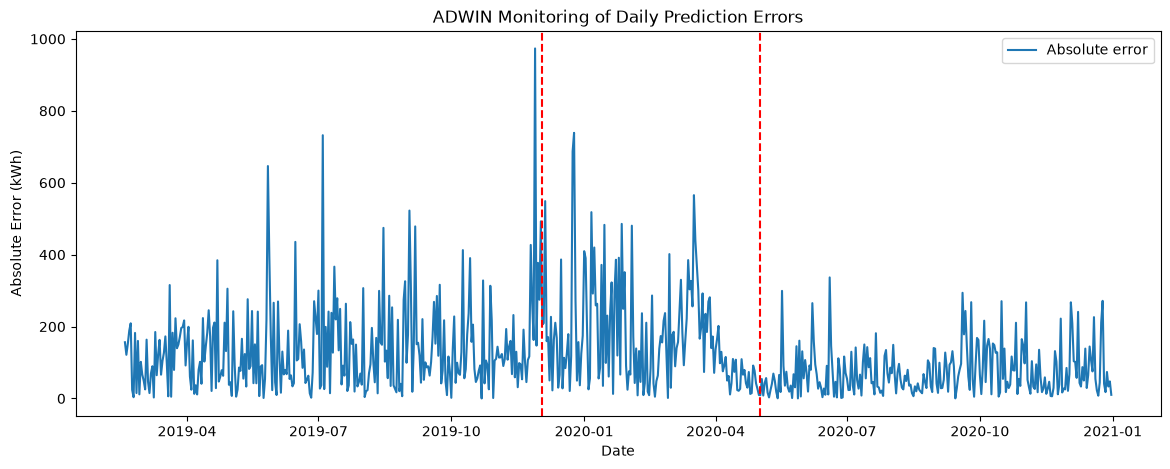

In [70]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_results["date"],
    test_results["absoluteError"],
    label="Absolute error"
)

for drift_date in drift_days["date"]:
    
    plt.axvline(
        drift_date,
        color="red",
        linestyle="--"
    )

plt.title("ADWIN Monitoring of Daily Prediction Errors")
plt.xlabel("Date")
plt.ylabel("Absolute Error (kWh)")
plt.legend()
plt.show()

In [71]:
if len(drift_days) == 0:
    
    first_drift_date = None
    
    print("ADWIN did not detect drift.")

else:
    
    first_drift_date = drift_days.iloc[0]["date"]
    
    print("First drift detected on:")
    print(first_drift_date)

First drift detected on:
2019-12-03 00:00:00


In [72]:
if first_drift_date is not None:
    
    evaluation_start_date = (
        first_drift_date
        + pd.Timedelta(days=1)
    )
    
    print("Retrain after:")
    print(first_drift_date)
    
    print("Begin new predictions on:")
    print(evaluation_start_date)

Retrain after:
2019-12-03 00:00:00
Begin new predictions on:
2019-12-04 00:00:00


In [73]:
if first_drift_date is not None:
    
    retraining_df = model_df[
        model_df["date"] <= first_drift_date
    ].copy()
    
    remaining_test_df = test_df[
        test_df["date"] > first_drift_date
    ].copy()
    
    print(
        "Retraining records:",
        len(retraining_df)
    )
    
    print(
        "Remaining test records:",
        len(remaining_test_df)
    )
    
    print(
        "Remaining test range:",
        remaining_test_df["date"].min(),
        "to",
        remaining_test_df["date"].max()
    )

Retraining records: 3022
Remaining test records: 394
Remaining test range: 2019-12-04 00:00:00 to 2020-12-31 00:00:00


In [74]:
if selected_model_name == "Random Forest":
    
    adwin_model = RandomForestRegressor(
        n_estimators=int(
            best_rf_settings["nEstimators"]
        ),
        max_depth=int(
            best_rf_settings["maxDepth"]
        ),
        min_samples_leaf=int(
            best_rf_settings["minSamplesLeaf"]
        ),
        random_state=42
    )

else:
    
    adwin_model = XGBRegressor(
        n_estimators=int(
            best_xgb_settings["nEstimators"]
        ),
        learning_rate=float(
            best_xgb_settings["learningRate"]
        ),
        max_depth=int(
            best_xgb_settings["maxDepth"]
        ),
        random_state=42,
        objective="reg:squarederror"
    )

In [75]:
adwin_model.fit(
    X_train_validation,
    y_train_validation
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [76]:
adwin_detector = drift.ADWIN(
    delta=0.002,
    clock=1
)

adwin_predictions = []
adwin_errors = []
adwin_detections = []

In [77]:
for index, row in test_df.iterrows():
    
    current_features = test_df.loc[
        [index],
        feature_columns
    ]
    
    prediction = adwin_model.predict(
        current_features
    )[0]
    
    actual_energy = row["dailyEnergy"]
    
    absolute_error = abs(
        actual_energy - prediction
    )
    
    adwin_detector.update(
        absolute_error
    )
    
    drift_today = (
        adwin_detector.drift_detected
    )
    
    adwin_predictions.append(
        prediction
    )
    
    adwin_errors.append(
        absolute_error
    )
    
    adwin_detections.append(
        drift_today
    )
    
    if drift_today:
        
        available_data = model_df[
            model_df["date"] <= row["date"]
        ]
        
        adwin_model.fit(
            available_data[feature_columns],
            available_data[target_column]
        )
        
        adwin_detector = drift.ADWIN(
            delta=0.002,
            clock=1
        )

In [78]:
adwin_results = test_df[
    ["date", "dailyEnergy"]
].copy()

adwin_results = (
    adwin_results
    .reset_index(drop=True)
)

adwin_results["adwinPrediction"] = (
    adwin_predictions
)

adwin_results["absoluteError"] = (
    adwin_errors
)

adwin_results["driftDetected"] = (
    adwin_detections
)

adwin_drift_days = adwin_results[
    adwin_results["driftDetected"] == True
][
    [
        "date",
        "absoluteError"
    ]
]

print(
    "ADWIN retrainings:",
    len(adwin_drift_days)
)

adwin_drift_days

ADWIN retrainings: 2


,date,absoluteError
289,2019-12-03,205.617554
437,2020-04-29,57.949173


In [79]:
if len(adwin_drift_days) == 0:
    
    first_adwin_drift_date = None
    
    print("No ADWIN drift was detected.")

else:
    
    first_adwin_drift_date = (
        adwin_drift_days.iloc[0]["date"]
    )
    
    comparison_start_date = (
        first_adwin_drift_date
        + pd.Timedelta(days=1)
    )
    
    print("First ADWIN drift:")
    print(first_adwin_drift_date)
    
    print("Fair comparison begins:")
    print(comparison_start_date)

First ADWIN drift:
2019-12-03 00:00:00
Fair comparison begins:
2019-12-04 00:00:00


In [80]:
if selected_model_name == "Random Forest":
    
    monthly_model = RandomForestRegressor(
        n_estimators=int(
            best_rf_settings["nEstimators"]
        ),
        max_depth=int(
            best_rf_settings["maxDepth"]
        ),
        min_samples_leaf=int(
            best_rf_settings["minSamplesLeaf"]
        ),
        random_state=42
    )

else:
    
    monthly_model = XGBRegressor(
        n_estimators=int(
            best_xgb_settings["nEstimators"]
        ),
        learning_rate=float(
            best_xgb_settings["learningRate"]
        ),
        max_depth=int(
            best_xgb_settings["maxDepth"]
        ),
        random_state=42,
        objective="reg:squarederror"
    )

In [81]:
monthly_model.fit(
    X_train_validation,
    y_train_validation
)

monthly_predictions = []
monthly_errors = []
monthly_retraining_dates = []

In [82]:
for position in range(len(test_df)):
    
    current_row = test_df.iloc[position]
    
    current_features = test_df.iloc[
        [position]
    ][feature_columns]
    
    prediction = monthly_model.predict(
        current_features
    )[0]
    
    actual_energy = current_row[
        "dailyEnergy"
    ]
    
    absolute_error = abs(
        actual_energy - prediction
    )
    
    monthly_predictions.append(
        prediction
    )
    
    monthly_errors.append(
        absolute_error
    )
    
    # Check whether another test day remains.
    if position < len(test_df) - 1:
        
        current_date = current_row["date"]
        
        next_date = test_df.iloc[
            position + 1
        ]["date"]
        
        month_has_ended = (
            current_date.month != next_date.month
            or current_date.year != next_date.year
        )
        
        if month_has_ended:
            
            available_data = model_df[
                model_df["date"] <= current_date
            ]
            
            monthly_model.fit(
                available_data[feature_columns],
                available_data[target_column]
            )
            
            monthly_retraining_dates.append(
                current_date
            )

In [83]:
monthly_results = test_df[
    ["date", "dailyEnergy"]
].copy()

monthly_results = (
    monthly_results
    .reset_index(drop=True)
)

monthly_results["monthlyPrediction"] = (
    monthly_predictions
)

monthly_results["absoluteError"] = (
    monthly_errors
)

monthly_results.head()

,date,dailyEnergy,monthlyPrediction,absoluteError
0,2019-02-17,740.988,897.423157,156.435157
1,2019-02-18,1027.115,1148.679077,121.564077
2,2019-02-19,1333.430,1181.286743,152.143257
3,2019-02-20,1527.817,1338.912598,188.904402
4,2019-02-21,1645.832,1436.757202,209.074798


In [84]:
print(
    "Number of monthly retrainings:",
    len(monthly_retraining_dates)
)

monthly_retraining_dates

Number of monthly retrainings: 22


[Timestamp('2019-02-28 00:00:00'),
 Timestamp('2019-03-31 00:00:00'),
 Timestamp('2019-04-30 00:00:00'),
 Timestamp('2019-05-31 00:00:00'),
 Timestamp('2019-06-30 00:00:00'),
 Timestamp('2019-07-31 00:00:00'),
 Timestamp('2019-08-31 00:00:00'),
 Timestamp('2019-09-30 00:00:00'),
 Timestamp('2019-10-31 00:00:00'),
 Timestamp('2019-11-30 00:00:00'),
 Timestamp('2019-12-31 00:00:00'),
 Timestamp('2020-01-31 00:00:00'),
 Timestamp('2020-02-29 00:00:00'),
 Timestamp('2020-03-31 00:00:00'),
 Timestamp('2020-04-30 00:00:00'),
 Timestamp('2020-05-31 00:00:00'),
 Timestamp('2020-06-30 00:00:00'),
 Timestamp('2020-07-31 00:00:00'),
 Timestamp('2020-08-31 00:00:00'),
 Timestamp('2020-09-30 00:00:00'),
 Timestamp('2020-10-31 00:00:00'),
 Timestamp('2020-11-30 00:00:00')]

In [85]:
frozen_results = test_results[
    [
        "date",
        "dailyEnergy",
        "selectedPrediction"
    ]
].copy()

frozen_results = frozen_results.rename(
    columns={
        "selectedPrediction": "frozenPrediction"
    }
)

In [86]:
strategy_results = frozen_results.merge(
    monthly_results[
        ["date", "monthlyPrediction"]
    ],
    on="date"
)

strategy_results = strategy_results.merge(
    adwin_results[
        ["date", "adwinPrediction"]
    ],
    on="date"
)

strategy_results.head()

,date,dailyEnergy,frozenPrediction,monthlyPrediction,adwinPrediction
0,2019-02-17,740.988,897.423157,897.423157,897.423157
1,2019-02-18,1027.115,1148.679077,1148.679077,1148.679077
2,2019-02-19,1333.430,1181.286743,1181.286743,1181.286743
3,2019-02-20,1527.817,1338.912598,1338.912598,1338.912598
4,2019-02-21,1645.832,1436.757202,1436.757202,1436.757202


In [87]:
comparison_results = strategy_results[
    strategy_results["date"]
    >= comparison_start_date
].copy()

comparison_results = (
    comparison_results
    .reset_index(drop=True)
)

print(
    "Comparison begins:",
    comparison_results["date"].min()
)

print(
    "Comparison ends:",
    comparison_results["date"].max()
)

print(
    "Evaluated days:",
    len(comparison_results)
)

comparison_results.head()

Comparison begins: 2019-12-04 00:00:00
Comparison ends: 2020-12-31 00:00:00
Evaluated days: 394


,date,dailyEnergy,frozenPrediction,monthlyPrediction,adwinPrediction
0,2019-12-04,1442.256,1232.682861,1228.501587,1235.840088
1,2019-12-05,1804.664,1255.768188,1250.892822,1238.890503
2,2019-12-06,1520.553,1361.213135,1351.005493,1330.569824
3,2019-12-07,922.700,1093.503784,1106.613281,1092.785645
4,2019-12-08,914.898,864.696594,896.356018,903.022278


In [88]:
frozen_mae = mean_absolute_error(
    comparison_results["dailyEnergy"],
    comparison_results["frozenPrediction"]
)

frozen_rmse = np.sqrt(
    mean_squared_error(
        comparison_results["dailyEnergy"],
        comparison_results["frozenPrediction"]
    )
)

monthly_mae = mean_absolute_error(
    comparison_results["dailyEnergy"],
    comparison_results["monthlyPrediction"]
)

monthly_rmse = np.sqrt(
    mean_squared_error(
        comparison_results["dailyEnergy"],
        comparison_results["monthlyPrediction"]
    )
)

adwin_mae = mean_absolute_error(
    comparison_results["dailyEnergy"],
    comparison_results["adwinPrediction"]
)

adwin_rmse = np.sqrt(
    mean_squared_error(
        comparison_results["dailyEnergy"],
        comparison_results["adwinPrediction"]
    )
)

In [89]:
maintenance_comparison = pd.DataFrame(
    {
        "strategy": [
            "Frozen",
            "Monthly",
            "ADWIN"
        ],
        "MAE": [
            frozen_mae,
            monthly_mae,
            adwin_mae
        ],
        "RMSE": [
            frozen_rmse,
            monthly_rmse,
            adwin_rmse
        ],
        "evaluatedDays": [
            len(comparison_results),
            len(comparison_results),
            len(comparison_results)
        ]
    }
)

maintenance_comparison = (
    maintenance_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
    .round(2)
)

maintenance_comparison

,strategy,MAE,RMSE,evaluatedDays
0,Monthly,107.60,153.63,394
1,ADWIN,107.65,156.85,394
2,Frozen,110.99,159.29,394
